In [177]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import CLIPProcessor, CLIPModel
from tqdm import tqdm
import os

In [178]:
root_path = "/home/stefan/ioai-prep/kits/rooms"
seed = 42

device = "cuda" if torch.cuda.is_available() else "cpu"

In [179]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-large-patch14")
clip_model = CLIPModel.from_pretrained("openai/clip-vit-large-patch14")

# Data

In [180]:
train_df = pd.read_csv(f"{root_path}/train.csv")
test_df = pd.read_csv(f"{root_path}/test.csv")

train_df.head()

,sample_id,question,answer,image_id
0,TRAIN0000,how many chairs are there,6,image888
1,TRAIN0001,how many picture are on the wall,2,image942
2,TRAIN0002,how many chairs are there,10,image1404
3,TRAIN0003,how many monitors are there in the table,2,image528
4,TRAIN0004,how many containers are there,3,image872


In [ ]:
train_df = train_df[train_df['question'].str.len() <= 77]#.sample(frac=0.75, random_state=seed)

In [182]:
class CountingVQADataset(Dataset):
    def __init__(self, df, processor):
        self.df = df.reset_index(drop=True)
        self.image_dir = f"{root_path}/images"
        self.processor = processor

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, f"{row['image_id']}.png")

        image = Image.open(image_path).convert("RGB")

        question = row["question"]
        answer = row["answer"] if "answer" in self.df.columns else 0.0

        inputs = self.processor(
            text=question,
            images=image,
            return_tensors="pt",
            padding="max_length",
            max_length=77,
            truncation=True,
        )

        return {
            "pixel_values": inputs["pixel_values"].squeeze(0),
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "answer": torch.tensor(answer, dtype=torch.float32),
        }

    def __len__(self):
        return len(self.df)

In [183]:
train_dataset = CountingVQADataset(train_df, processor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True)

In [184]:
batch = next(iter(train_loader))
{k:batch[k].shape for k in batch.keys()}

{'pixel_values': torch.Size([32, 3, 224, 224]),
 'input_ids': torch.Size([32, 77]),
 'attention_mask': torch.Size([32, 77]),
 'answer': torch.Size([32])}

# Model

In [ ]:
class SpatialCountingModel(nn.Module):
    def __init__(self, clip_model, frozen=True):
        super().__init__()
        self.vision_model = clip_model.vision_model
        self.text_model = clip_model.text_model
        self.projection_dim = clip_model.config.projection_dim
        self.hidden_dim = clip_model.config.vision_config.hidden_size

        self.text_proj = clip_model.visual_projection
        self.text_to_hidden = nn.Linear(self.projection_dim, self.hidden_dim)

        if frozen:
            for param in self.vision_model.parameters():
                param.requires_grad = False
            for param in self.text_model.parameters():
                param.requires_grad = False

        self.attn = nn.MultiheadAttention(
            embed_dim=self.hidden_dim, num_heads=8, batch_first=True
        )

        self.regressor = nn.Sequential(
            nn.Linear(self.hidden_dim, 512),
            nn.LeakyReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        vision_outputs = self.vision_model(pixel_values=pixel_values)
        image_states = vision_outputs.last_hidden_state

        image_patches = image_states[:, 1:, :]

        text_outputs = self.text_model(
            input_ids=input_ids, attention_mask=attention_mask
        )
        text_embeds = text_outputs.pooler_output

        text_feat = self.text_to_hidden(text_embeds)  # (Batch, 1024)
        text_feat = text_feat.unsqueeze(1)  # (Batch, 1, 1024) -> Query

        attn_out, _ = self.attn(query=text_feat, key=image_patches, value=image_patches)

        # attn_out is (Batch, 1, 1024). This represents the image features relevant to the text.
        context_vector = attn_out.squeeze(1)

        # 4. Predict Count
        count = self.regressor(context_vector)
        return count.squeeze()

In [205]:
model = SpatialCountingModel(clip_model, frozen=True).to(device)

# sanity check
model(
    batch["pixel_values"].to(device),
    batch["input_ids"].to(device),
    batch["attention_mask"].to(device),
).shape

torch.Size([32])

# Training

In [224]:
losses = []
epochs = 40
lr = 1e-4

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
criterion = nn.L1Loss()
scaler = torch.amp.GradScaler(device)

In [225]:
for epoch in range(epochs):
    running_loss = 0

    for batch in tqdm(train_loader):
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        answers = batch["answer"].to(device)

        with torch.amp.autocast(device):
            predictions = model(pixel_values, input_ids, attention_mask).squeeze()
            loss = criterion(predictions, answers.float())

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        losses.append(loss.item())

    avg_loss = running_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1}/{epochs}, loss={avg_loss:.4f}")

100%|██████████| 30/30 [00:15<00:00,  1.88it/s]


Epoch 1/40, loss=2.5122


100%|██████████| 30/30 [00:15<00:00,  1.89it/s]


Epoch 2/40, loss=2.5731


100%|██████████| 30/30 [00:15<00:00,  1.88it/s]


...

Epoch 38/40, loss=2.2604


100%|██████████| 30/30 [00:14<00:00,  2.02it/s]


Epoch 39/40, loss=2.2604


100%|██████████| 30/30 [00:14<00:00,  2.03it/s]

Epoch 40/40, loss=2.2600


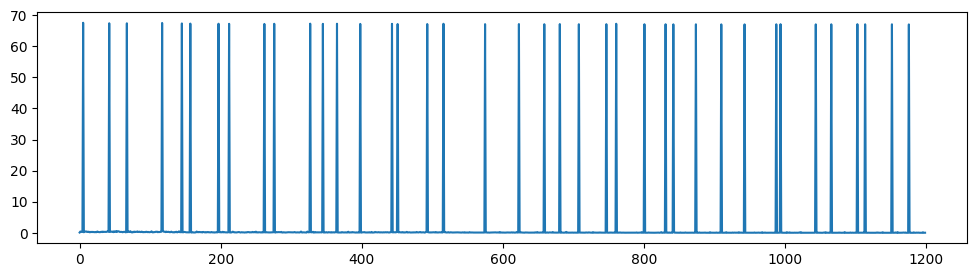

In [226]:
plt.figure(figsize=(12, 3))
plt.plot(losses)

In [227]:
1/0

ZeroDivisionError: division by zero

# Submission

In [ ]:
model.eval()
test_dataset = CountingVQADataset(test_df, processor)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

In [ ]:
predictions = []

with torch.no_grad():
    pbar = tqdm(test_loader, desc="Generating predictions")
    for batch in pbar:
        pixel_values = batch["pixel_values"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        pred = model(pixel_values, input_ids, attention_mask).squeeze().item()
        pred = max(0, int(round(pred)))
        predictions.append(pred)

Generating predictions: 100%|██████████| 367/367 [00:12<00:00, 29.29it/s]


In [ ]:
submission_df = pd.DataFrame({"sample_id": test_df["sample_id"], "answer": predictions})
submission_df.head()

,sample_id,answer
0,TEST0000,9
1,TEST0001,2
2,TEST0002,2
3,TEST0003,6
4,TEST0004,6


array([[<Axes: title={'center': 'answer'}>]], dtype=object)

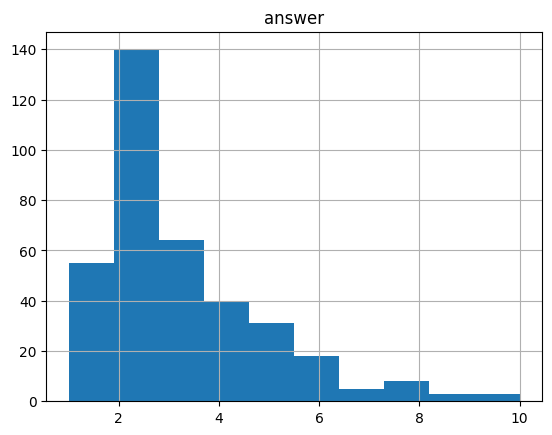

In [ ]:
submission_df.hist()

In [ ]:
submission_df.to_csv(f"{root_path}/submission.csv", index=False)